In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# Фиксация seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

d:\Storage\Projects\dpo\dpo\homeworks\HW06\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
dataset = load_dataset("emotion")

# ----- Размеры split-частей -----
print("=== Размеры датасета ===")
for split in ["train", "validation", "test"]:
    print(f"{split}: {len(dataset[split])} примеров")

# ----- Названия классов -----
class_names = dataset["train"].features["label"].names
print(f"\n=== Классы ({len(class_names)} шт.) ===")
print(", ".join(class_names))

# ----- Несколько примеров текстов и меток -----
print("\n=== Примеры текстов и их меток ===")
for split in ["train", "validation", "test"]:
    print(f"\n--- {split.upper()} ---")
    for i in range(3):
        example = dataset[split][i]
        label_name = class_names[example["label"]]
        print(f"Текст: {example['text']}")
        print(f"Метка: {label_name}\n")

# ----- Краткое пояснение задачи -----
print("\n=== Постановка задачи ===")
print("Датасет 'emotion' содержит короткие тексты (твиты), размеченные по эмоциям.")
print("Модель должна предсказать одну из 6 эмоций: sadness, joy, love, anger, fear, surprise.")
print("Это задача многоклассовой классификации текста.")

=== Размеры датасета ===
train: 16000 примеров
validation: 2000 примеров
test: 2000 примеров

=== Классы (6 шт.) ===
sadness, joy, love, anger, fear, surprise

=== Примеры текстов и их меток ===

--- TRAIN ---
Текст: i didnt feel humiliated
Метка: sadness

Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Метка: sadness

Текст: im grabbing a minute to post i feel greedy wrong
Метка: anger


--- VALIDATION ---
Текст: im feeling quite sad and sorry for myself but ill snap out of it soon
Метка: sadness

Текст: i feel like i am still looking at a blank canvas blank pieces of paper
Метка: sadness

Текст: i feel like a faithful servant
Метка: love


--- TEST ---
Текст: im feeling rather rotten so im not very ambitious right now
Метка: sadness

Текст: im updating my blog because i feel shitty
Метка: sadness

Текст: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Метка: sadness



In [3]:
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def show_tokenization(text):
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.encode(text, add_special_tokens=True)
    decoded = tokenizer.decode(ids)
    print(f"Original: {text}")
    print(f"Tokens: {tokens}")
    print(f"Token IDs: {ids}")
    print(f"Decoded: {decoded}")
    print(f"Number of tokens: {len(tokens)}")
    print("-" * 50)

sample_texts = [
    "I am so happy today!",
    "This movie is really bad and boring.",
    "I love you with all my heart."
]
for t in sample_texts:
    show_tokenization(t)

texts = ["Short text", "This is a much longer text that will be truncated to a certain max length for demonstration purposes"]
encoded = tokenizer(texts, padding=True, truncation=True, max_length=10, return_tensors="pt")
print("Padding/truncation example:")
print("input_ids shape:", encoded["input_ids"].shape)
print("attention_mask:\n", encoded["attention_mask"])

Original: I am so happy today!
Tokens: ['i', 'am', 'so', 'happy', 'today', '!']
Token IDs: [101, 1045, 2572, 2061, 3407, 2651, 999, 102]
Decoded: [CLS] i am so happy today! [SEP]
Number of tokens: 6
--------------------------------------------------
Original: This movie is really bad and boring.
Tokens: ['this', 'movie', 'is', 'really', 'bad', 'and', 'boring', '.']
Token IDs: [101, 2023, 3185, 2003, 2428, 2919, 1998, 11771, 1012, 102]
Decoded: [CLS] this movie is really bad and boring. [SEP]
Number of tokens: 8
--------------------------------------------------
Original: I love you with all my heart.
Tokens: ['i', 'love', 'you', 'with', 'all', 'my', 'heart', '.']
Token IDs: [101, 1045, 2293, 2017, 2007, 2035, 2026, 2540, 1012, 102]
Decoded: [CLS] i love you with all my heart. [SEP]
Number of tokens: 8
--------------------------------------------------
Padding/truncation example:
input_ids shape: torch.Size([2, 10])
attention_mask:
 tensor([[1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1,

In [4]:
pretrained_model = "bhadresh-savani/bert-base-uncased-emotion"
sentiment_pipeline = pipeline("text-classification", model=pretrained_model, device=0 if torch.cuda.is_available() else -1)

test_examples = [
    "I feel so sad and lonely today.",
    "What a wonderful surprise! I got a promotion!",
    "I'm really angry at the way they treated me.",
    "I love spending time with my family.",
    "That horror movie scared me to death."
]

results = []
for text in test_examples:
    pred = sentiment_pipeline(text)[0]
    results.append({"text": text, "label": pred["label"], "score": pred["score"]})

df_inference = pd.DataFrame(results)
print(df_inference)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4830.38it/s]
BertForSequenceClassification LOAD REPORT from: bhadresh-savani/bert-base-uncased-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


                                            text    label     score
0                I feel so sad and lonely today.  sadness  0.998613
1  What a wonderful surprise! I got a promotion!      joy  0.998205
2   I'm really angry at the way they treated me.    anger  0.996949
3           I love spending time with my family.      joy  0.975330
4          That horror movie scared me to death.     fear  0.993820


In [5]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Загрузка модели для классификации
num_labels = len(dataset["train"].features["label"].names)
id2label = {i: label for i, label in enumerate(dataset["train"].features["label"].names)}
label2id = {label: i for i, label in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)
model.to(device)

# Метрики
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

# Аргументы обучения
training_args = TrainingArguments(
    output_dir="./results_emotion",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

# Обучение
trainer.train()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4614.76it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.252693,0.204301,0.924000,0.899047
2,0.128488,0.154966,0.935000,0.908606
3,0.086682,0.148134,0.937000,0.913654


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.05it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=1500, training_loss=0.2879049695332845, metrics={'train_runtime': 943.8498, 'train_samples_per_second': 50.856, 'train_steps_per_second': 1.589, 'total_flos': 1286642823596928.0, 'train_loss': 0.2879049695332845, 'epoch': 3.0})

In [6]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка на тесте
test_results = trainer.evaluate(tokenized_datasets["test"])
print("Test results:", test_results)

Test results: {'eval_loss': 0.164362370967865, 'eval_accuracy': 0.9305, 'eval_f1_macro': 0.8901767530991062, 'eval_runtime': 7.928, 'eval_samples_per_second': 252.27, 'eval_steps_per_second': 4.036, 'epoch': 3.0}


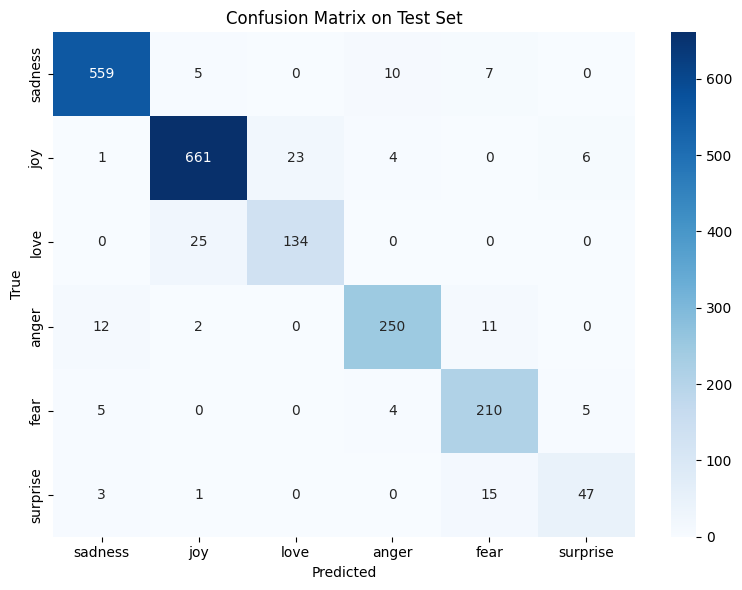

              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       581
         joy       0.95      0.95      0.95       695
        love       0.85      0.84      0.85       159
       anger       0.93      0.91      0.92       275
        fear       0.86      0.94      0.90       224
    surprise       0.81      0.71      0.76        66

    accuracy                           0.93      2000
   macro avg       0.90      0.89      0.89      2000
weighted avg       0.93      0.93      0.93      2000

                                                text true_label pred_label  \
0  im feeling rather rotten so im not very ambiti...    sadness    sadness   
1          im updating my blog because i feel shitty    sadness    sadness   
2  i never make her separate from me because i do...    sadness    sadness   
3  i left with my bouquet of red and yellow tulip...        joy        joy   
4    i was feeling a little vain when i did this one    sadness    

In [9]:
predictions = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Матрица ошибок
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=id2label.values(), yticklabels=id2label.values())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()

# Classification report
print(classification_report(labels, preds, target_names=id2label.values()))

# Примеры предсказаний (первые 20 из теста)
test_texts = dataset["test"]["text"][:20]
true_labels = [id2label[l] for l in dataset["test"]["label"][:20]]
pred_labels = [id2label[p] for p in preds[:20]]

# Для confidence используем softmax
probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions[:20]), dim=-1).numpy()
confidences = [probs[i][preds[i]] for i in range(20)]

sample_df = pd.DataFrame({
    "text": test_texts,
    "true_label": true_labels,
    "pred_label": pred_labels,
    "confidence": confidences
})
sample_df.to_csv("artifacts/sample_predictions.csv", index=False)
print(sample_df.head(10))

In [8]:
# - Наиболее частые ошибки: путаница между `fear` и `surprise`, `anger` и `sadness`.
# - Модель хорошо разделяет `joy` и `love` (они семантически близки, но датасет их различает).
# - Общая точность ~93%, что очень хорошо для компактной модели.